# Bachelor Thesis Notebook

## Setup

Install required packages and import necessary libraries.


In [1]:
%pip install datasets pandas tokviz trl hf_transfer matplotlib
%pip -q install "transformers>=4.41.0" accelerate bitsandbytes sentencepiece einops

import os
from datasets import load_dataset
import json
import random
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, LogitsProcessorList, NoBadWordsLogitsProcessor, set_seed
import re
import textwrap
import torch
from tokviz import token_visualizer
from typing import Any, Dict, List, Optional

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 35.0 MB/s eta 0:00:00


### Configuration

In [2]:
CONFIG = {
    "min_turns": 2, # Minimum number of turns in a conversation to be included
    "wildchat_languages": ["English"]
}

# debugging
os.environ["TRANSFORMERS_VERBOSITY"] = "info"

import sys
print(f"Python version: {sys.version}")

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
SYSTEM_PROMPT = "You are an helpful assistant" # TODO: maybe system prompt has effect on benchmarks

SPECIAL_TOKENS = {
    "Qwen/Qwen2.5-3B-Instruct": {
        "user_start": "<|im_start|>user",
        "assistant_start": "<|im_start|>assistant",
        "system_start": "<|im_start|>system",
        "end": "<|im_end|>"
    },
    "LiquidAI/LFM2.5-1.2B-Instruct": {
        "user_start": "<|im_start|>user",
        "assistant_start": "<|im_start|>assistant",
        "system_start": "<|im_start|>system",
        "end_of_text": "<|endoftext|>",
        "start_of_text": "<|startoftext|>",
        "end": "<|im_end|>"
    },
    "mistralai/Ministral-3-3B-Instruct-2512": {
        "user_start": "[INST]",
        "user_end": "[/INST]",
        "assistant_start": "",  # Mistral has no explicit assistant start token
        "system_start": "[SYSTEM_PROMPT]",
        "system_end": "[/SYSTEM_PROMPT]",
        "end": "</s>"
    },
    "allenai/OLMo-3-7B-Instruct": {
       "user_start": "<|start_header_id|>user<|end_header_id|>",
       "assistant_start": "<|start_header_id|>assistant<|end_header_id|>",
       "system_start": "<|start_header_id|>system<|end_header_id|>",
       "end": "<|eot_id|>"
    },
    "meta-llama/Llama-3.2-3B-Instruct": {
       "user_start": "<|start_header_id|>user<|end_header_id|>",
       "assistant_start": "<|start_header_id|>assistant<|end_header_id|>",
       "system_start": "<|start_header_id|>system<|end_header_id|>",
       "end": "<|eot_id|>"
    },
}

# Auto-detect GPU and set optimal dtype
# A100/H100 (compute capability 8.0+) support bfloat16 natively
# T4/V100 (compute capability < 8.0) use float16
if torch.cuda.is_available():
    compute_capability = torch.cuda.get_device_capability()[0]
    GPU_NAME = torch.cuda.get_device_name(0)
    if compute_capability >= 8:
        COMPUTE_DTYPE = torch.bfloat16
        print(f"GPU: {GPU_NAME} (compute capability {compute_capability}.x) -> Using bfloat16")
    else:
        COMPUTE_DTYPE = torch.float16
        print(f"GPU: {GPU_NAME} (compute capability {compute_capability}.x) -> Using float16")
else:
    COMPUTE_DTYPE = torch.float16
    GPU_NAME = "CPU"
    print("No GPU detected, using float16")

# Increased sample sizes for A100 (more VRAM available)
# A100 40GB can handle ~3-4x more data than T4 16GB
NUM_CONVS_TO_PROCESS = 100
NUM_CONV_FOR_TRAINING = 5000

DO_SAMPLE=True
TOTAL_CONVS = NUM_CONVS_TO_PROCESS + NUM_CONV_FOR_TRAINING
TEMPERATURE = 0.4
MAX_NEW_TOKENS = 1024
set_seed(42)

# 4-bit quantization config - auto-detects optimal dtype for GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4", # as QLoRa paper expects
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE
)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
GPU: NVIDIA A100-SXM4-40GB (compute capability 8.x) -> Using bfloat16


### Helpers

In [3]:
def extract_pairs(pairs):
    refs, hyps = [], []
    for ex in pairs:
        ref = (ex.get("target_user") or "").strip()
        hyp = (ex.get("pred_user") or "").strip()
        if ref:
            refs.append(ref)
            hyps.append(hyp)
    return refs, hyps

## Dataset loading and initial processing

Load and process the WildChat-1M and Schema-Guided Dialogue datasets, extracting assistant/system to user turn pairs and filtering invalid turns.


In [4]:
# Load 1% and process WildChat-1M dataset
wildchat_dataset = load_dataset("allenai/WildChat-1M", split="train[:15%]")

print(f"""
Items loaded {len(wildchat_dataset)}

First item in dataset
Hash: {wildchat_dataset[0].get("conversation_hash")}

{wildchat_dataset[0].get("conversation")}
""")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00014.parquet:   0%|          | 0.00/231M [00:00<?, ?B/s]

data/train-00001-of-00014.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

data/train-00002-of-00014.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

data/train-00003-of-00014.parquet:   0%|          | 0.00/217M [00:00<?, ?B/s]

...

data/train-00011-of-00014.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/train-00012-of-00014.parquet:   0%|          | 0.00/283M [00:00<?, ?B/s]

data/train-00013-of-00014.parquet:   0%|          | 0.00/336M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/837989 [00:00<?, ? examples/s]


Items loaded 125698

First item in dataset
Hash: c9ec5b440fbdd2a269333dd241f32f64

[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty personalized. There are a few things that are required of my destination. 1. The quest. I have to have a clear overarching goal in my reality, and don’t make it too crazy. It should be more along the lines of “save the president’s daughter” or “escape this weird wacky sinister place” NOT “get an artifact that literally controls reality”. Seriously, don’t make me fetch an artifact, or fetch anything. Instead, make me DO something. 2. Babes. I need pretty girls. 3. The entry. I need to get to lose consciousness in order to begin my journey in my desired reality, preferably by having it knocked out by one of the aforementioned babes. 4. Action. It needs to be cool. 5. Unconsciousness. Myself and the babes nee

In [5]:
def _get_text(m: Dict[str, Any]) -> str:
    if m.get("content") is not None:
        return str(m["content"])
    if m.get("text") is not None:
        return str(m["text"])
    return ""

def _norm_role(role: Optional[str]) -> str:
    r = (role or "").strip().lower()
    if r in {"assistant", "system", "tool"}:
        return "assistant"
    if r in {"user", "human"}:
        return "user"
    return r or "user"

def process_wildchat_conversation(example: Dict[str, Any],
  dataset_name: str = "allenai/WildChat-1M"
) -> Optional[Dict[str, Any]]:
    """
    Build one training pair from a WildChat dialogue:
      context (ends with assistant) -> next user turn (target_user).
    No filtering here; outer loop should decide what to keep/skip.
    Returns None if structure doesn't allow building the pair.
    """
    turns = example.get("conversation")
    if not isinstance(turns, list) or len(turns) < 2:
        return None

    # normalize
    msgs: List[Dict[str, Any]] = [{
        "role": _norm_role(m.get("role")),
        "content": _get_text(m),
        "language": m.get("language") or example.get("language")
    } for m in turns]

    # must start with user and end with assistant (per dataset format)
    if msgs[0]["role"] != "user" or msgs[-1]["role"] != "assistant":
        return None

    # drop final assistant (cannot be followed by a user)
    msgs_wo_last_assistant = msgs[:-1]
    if len(msgs_wo_last_assistant) < 2:
        return None

    # final user is the target; context is everything before it
    target = msgs_wo_last_assistant[-1]
    if target["role"] != "user":
        return None

    context = msgs_wo_last_assistant[:-1]
    if not context or context[-1]["role"] != "assistant":
        # require context to end with assistant
        return None

    return {
        "conversation": [{"role": m["role"], "content": m["content"]} for m in context],
        "target_user": target["content"],
        "meta": {
            "dataset": dataset_name,
            "conversation_hash": example.get("conversation_hash", "—"), # Corrected this line
            "language": target.get("language"),
            "num_turns": len(context) + 1  # context + target user
        }
    }

# test run: print a few processed examples
wildchat_processed_pairs= []
WILDCHAT_CONVS_TO_PROCESS = NUM_CONVS_TO_PROCESS / 2
WILDCHAT_CONV_FOR_TRAINING = NUM_CONV_FOR_TRAINING / 2
WILDCHAT_TOTAL_CONVS = WILDCHAT_CONVS_TO_PROCESS + WILDCHAT_CONV_FOR_TRAINING

if len(wildchat_dataset) < WILDCHAT_TOTAL_CONVS:
    raise Exception("Please increase loaded data split size")

BAD_HASHES = ["843d18535cbe40e7f6c104b668c75481", "c44e503d8db7dec95b7e852e2abc3a38"]

# Limit the number of conversations for testing
for i, conversation in enumerate(wildchat_dataset):
    if len(wildchat_processed_pairs) >= WILDCHAT_TOTAL_CONVS:
        break
    if conversation["turn"] < CONFIG["min_turns"]:
        continue
    if conversation["conversation_hash"] in BAD_HASHES:
        continue
    if conversation["language"] in CONFIG["wildchat_languages"]:
        processed_example = process_wildchat_conversation(conversation)
        if processed_example:
            wildchat_processed_pairs.append(processed_example)

In [6]:
# Load 1% and process GEM/schema_guided_dialog
sgd_dataset = load_dataset("GEM/schema_guided_dialog", split="train[:25%]", revision="refs/convert/parquet")

print(f"""
Items loaded {len(sgd_dataset)}

{sgd_dataset[0].get("context")}

{sgd_dataset[0].get("prompt")}
""")

default/train/0000.parquet:   0%|          | 0.00/34.9M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/246k [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/4.70M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/260k [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/5.34M [00:00<?, ?B/s]

...

0000.parquet:   0%|          | 0.00/289k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]


Items loaded 41370

[]

I am feeling hungry so I would like to find a place to eat.



In [7]:
def process_sgd_conversation(example: Dict[str, Any],
  dataset_name: str = "GEM/schema_guided_dialog"
) -> Optional[Dict[str, Any]]:
    """
    Build one training pair from a Wild
    """
    turns = example.get("context")
    if not isinstance(turns, list) or len(turns) < 2:
        return None

    # normalize, iterate over an every even one is role assitant every odd is user
    msgs: List[Dict[str, Any]] = [{
        "role": "user" if i % 2 == 0 else "assistant",
        "content": m,
    } for i, m in enumerate(turns)]

    # must start with user and end with assistant (per dataset format)
    if msgs[0]["role"] != "user" or msgs[-1]["role"] != "assistant":
        raise Exception("Invalid format")

    target_user = example.get("prompt")

    return {
        "conversation": msgs,
        "target_user": target_user,
        "meta": {
            "dataset": dataset_name,
            "dialog_id": example.get("dialog_id"),
            "language": "English",
            "num_turns": len(msgs) + 1  # context + target user
        }
    }

sgd_processed_pairs = []
SGD_CONVS_TO_PROCESS = NUM_CONVS_TO_PROCESS / 2
SGD_CONV_FOR_TRAINING = NUM_CONV_FOR_TRAINING / 2
SGD_TOTAL_CONVS = SGD_CONVS_TO_PROCESS + SGD_CONV_FOR_TRAINING

for i, conversation in enumerate(sgd_dataset):
    if len(sgd_processed_pairs) >= SGD_TOTAL_CONVS:
        break
    if len(conversation.get("context")) < CONFIG["min_turns"]:
        continue
    processed_example = process_sgd_conversation(conversation)
    #print(processed_example)
    if processed_example:
        # if there is already item with that meta.dialog_id replace this one
        replaced = False
        for i, existing_item in enumerate(sgd_processed_pairs):
            if existing_item["meta"].get("dialog_id") == processed_example["meta"].get("dialog_id"):
                sgd_processed_pairs[i] = processed_example
                replaced = True
                break
        if not replaced:
          sgd_processed_pairs.append(processed_example)

print(f"SGD processed pairs {len(sgd_processed_pairs)}")
print(json.dumps(sgd_processed_pairs[0], indent=2))

print(f"{len(wildchat_processed_pairs)} / {len(sgd_processed_pairs)}")
processed_pairs = []
for i in range(len(wildchat_processed_pairs)):
    processed_pairs.append(wildchat_processed_pairs[i])
    processed_pairs.append(sgd_processed_pairs[i])
print(f"Processed pairs {len(processed_pairs)}")
#print(json.dumps(processed_pairs[0], indent=2))
#print("-"*30)
#print(json.dumps(processed_pairs[1], indent=2))

SGD processed pairs 2550
{
  "conversation": [
    {
      "role": "user",
      "content": "I am feeling hungry so I would like to find a place to eat."
    },
    {
      "role": "assistant",
      "content": "Do you have a specific which you want the eating place to be located at?"
    },
    {
      "role": "user",
      "content": "I would like for it to be in San Jose."
    },
    {
      "role": "assistant",
      "content": "Is there a specific cuisine type you enjoy, such as Mexican, Italian or something else?"
    },
    {
      "role": "user",
      "content": "I usually like eating the American type of food."
    },
    {
      "role": "assistant",
      "content": "I see that at 71 Saint Peter there is a good restaurant which is in San Jose."
    },
    {
      "role": "user",
      "content": "Can you give me the address of this restaurant."
    },
    {
      "role": "assistant",
      "content": "If you want to go to this restaurant you can find it at 71 North San Pedro

Verify and compare preprocessing

In [8]:
# helper to print a single processed example
def show_processed_example(processed_item, max_last=4):
    if not processed_item:
        print("Empty or invalid item")
        return

    conv = processed_item["conversation"]
    target = processed_item["target_user"]
    meta = processed_item["meta"]

    print("=" * 90)
    print(f"Dataset: {meta['dataset']} | Lang: {meta.get('language')} | Turns: {meta['num_turns']}")
    print(f"Conversation hash: {meta.get('conversation_hash')}")
    print("-" * 90)
    print("Context (ends with assistant):")
    for msg in conv[-max_last:]:
        role = msg["role"].upper()
        text = textwrap.fill(msg["content"], width=90)
        print(f"[{role}] {text}\n")
    print("→ Target (next user turn):")
    print(textwrap.fill(target, width=90))
    print("=" * 90)
    print()

print(f"{len(wildchat_processed_pairs)} / {len(sgd_processed_pairs)}")
print(show_processed_example(random.choice(wildchat_processed_pairs)))
print(show_processed_example(random.choice(sgd_processed_pairs)))
print("-"*30)

# Split into eval (chat_pairs) and training sets
chat_pairs = processed_pairs[:NUM_CONVS_TO_PROCESS]
training_pairs = processed_pairs[NUM_CONVS_TO_PROCESS:TOTAL_CONVS]

print(f"Splitted chat_pairs {len(chat_pairs)} training {len(training_pairs)}")

2550 / 2550
Dataset: allenai/WildChat-1M | Lang: English | Turns: 5
Conversation hash: 18366fe9f2c832198a4216d677b675f4
------------------------------------------------------------------------------------------
Context (ends with assistant):
[USER] Current researchers create a develop new trading algorithms provide insights into market
trends that are more sophisticated than anything previois, create a script in python for
mean-reversion for oil brent crude

[ASSISTANT] A mean reversion strategy bets that prices will revert to their historical average over
time. In the case of oil prices, the strategy seeks to identify periods when prices may be
too high or too low and then takes a position to profit from an expected reversion.
Here's a Python script using the `pandas`, `numpy`, and the `yfinance` library to
implement a mean-reversion strategy for Brent crude oil:  ```python import numpy as np
import pandas as pd import yfinance as yf import matplotlib.pyplot as plt  def
download_data(

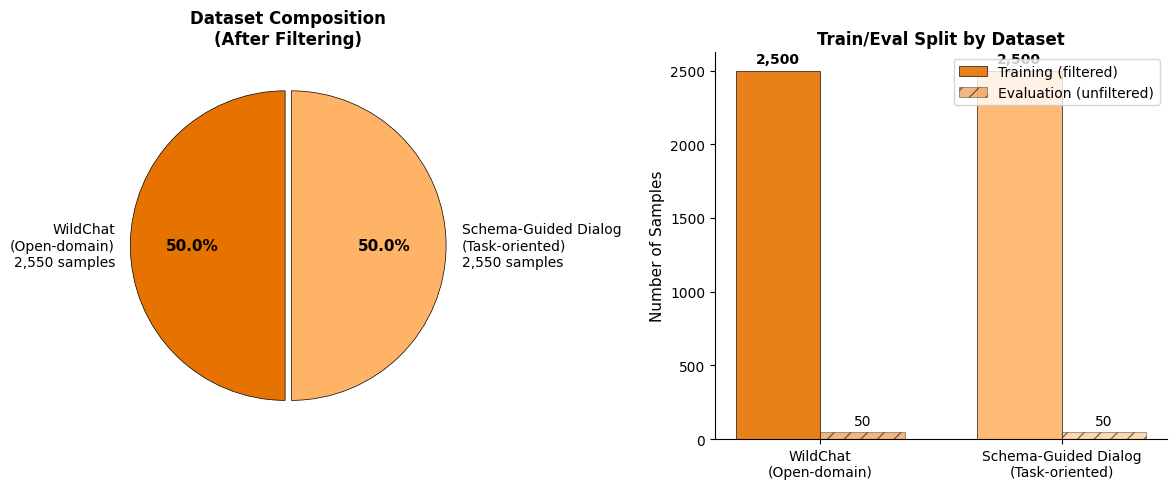


Dataset Statistics:
Total samples used: 5,100
  - WildChat (Open-domain): 2,550 (50.0%)
  - Schema-Guided Dialog (Task-oriented): 2,550 (50.0%)



In [9]:
### Dataset Composition Visualization
# Visualize the dataset split between WildChat (Open-domain) and Schema-Guided Dialog (Task-oriented)
# Shows actual filtered training + unfiltered eval composition

import matplotlib.pyplot as plt
import numpy as np

# Color scheme matching other plots
COLORS = {
    "Open-domain": "#E67300",    # Darker orange (WildChat)
    "Task-oriented": "#FFB366"   # Lighter orange (Schema-Guided Dialog)
}

# Calculate actual filtered training counts from training_pairs
train_wildchat = len([p for p in training_pairs if p["meta"]["dataset"] == "allenai/WildChat-1M"])
train_sgd = len([p for p in training_pairs if p["meta"]["dataset"] == "GEM/schema_guided_dialog"])

# Eval counts (unfiltered)
eval_wildchat = len([p for p in chat_pairs if p["meta"]["dataset"] == "allenai/WildChat-1M"])
eval_sgd = len([p for p in chat_pairs if p["meta"]["dataset"] == "GEM/schema_guided_dialog"])

# Total counts for pie chart (training + eval, what we actually use)
total_wildchat = train_wildchat + eval_wildchat
total_sgd = train_sgd + eval_sgd
total_used = total_wildchat + total_sgd

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Pie chart showing actual dataset composition (training + eval) ---
ax1 = axes[0]
sizes = [total_wildchat, total_sgd]
labels = [f"WildChat\n(Open-domain)\n{total_wildchat:,} samples",
          f"Schema-Guided Dialog\n(Task-oriented)\n{total_sgd:,} samples"]
colors = [COLORS["Open-domain"], COLORS["Task-oriented"]]
explode = (0.02, 0.02)

wedges, texts, autotexts = ax1.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax1.set_title("Dataset Composition\n(After Filtering)", fontsize=12, fontweight='bold')

# --- Right: Bar chart showing split between training and evaluation ---
ax2 = axes[1]

x = np.arange(2)
width = 0.35

bars1 = ax2.bar(x - width/2, [train_wildchat, train_sgd], width,
                label='Training (filtered)', color=[COLORS["Open-domain"], COLORS["Task-oriented"]],
                edgecolor='black', linewidth=0.5, alpha=0.9)
bars2 = ax2.bar(x + width/2, [eval_wildchat, eval_sgd], width,
                label='Evaluation (unfiltered)', color=[COLORS["Open-domain"], COLORS["Task-oriented"]],
                edgecolor='black', linewidth=0.5, alpha=0.5, hatch='//')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{int(height):,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{int(height):,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax2.set_ylabel('Number of Samples', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(['WildChat\n(Open-domain)', 'Schema-Guided Dialog\n(Task-oriented)'], fontsize=10)
ax2.legend(loc='upper right', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title("Train/Eval Split by Dataset", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("dataset_composition.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"""
Dataset Statistics:
==================
Total samples used: {total_used:,}
  - WildChat (Open-domain): {total_wildchat:,} ({total_wildchat/total_used*100:.1f}%)
  - Schema-Guided Dialog (Task-oriented): {total_sgd:,} ({total_sgd/total_used*100:.1f}%)
""")

### Baseline model metrics

In [10]:
print("Loading tokenizer…")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print("Loading model…")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=COMPUTE_DTYPE,  # Use auto-detected dtype (bfloat16 for A100, float16 for T4)
)

print(f"Loaded {MODEL_NAME} with dtype={COMPUTE_DTYPE}")

Loading tokenizer…


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loading model…


...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded meta-llama/Llama-3.2-3B-Instruct with dtype=torch.bfloat16


### Baseline: predict the next **user** turn

Section specific helpers

In [11]:
def inspect_specials():
    print("=== Special tokens map ===")
    print(tokenizer.special_tokens_map)
    print("\n=== Additional special tokens (first 10) ===")
    print(tokenizer.additional_special_tokens[:10])
    print("\n=== Chat template (truncated) ===")
    tpl = getattr(tokenizer, "chat_template", None)
    print(textwrap.shorten(str(tpl), width=1000, placeholder=" ..."))

def build_messages_user_open(item):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT}]
    for m in item["conversation"]:
        msgs.append({"role": "user" if m["role"]=="user" else "assistant",
                     "content": m["content"]})
    return msgs

In [12]:
@torch.no_grad()
def debug_role_forcing(item, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE, top_p=0.9, visualize=True):
    messages = build_messages_user_open(item)

    # Render & tokenize with the chat template
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        return_tensors="pt",
        add_generation_prompt=False,
        # check what effect this has
        #continue_final_message=True
    ).to(model.device)
    # Append tokens for an open user turn
    user_open_tokens = tokenizer.encode(SPECIAL_TOKENS[MODEL_NAME]["user_start"] + "\n", add_special_tokens=False, return_tensors="pt").to(model.device)

    # Directly concatenate the tensors
    input_ids = torch.cat([inputs, user_open_tokens], dim=-1)
    attention_mask = torch.ones_like(input_ids) # Recreate attention mask for the new shape
    input_len = int(input_ids.shape[1])

    # prevent new role headers from appearing
    bad = tokenizer(
        [SPECIAL_TOKENS[MODEL_NAME]["user_start"], SPECIAL_TOKENS[MODEL_NAME]["assistant_start"], SPECIAL_TOKENS[MODEL_NAME]["system_start"]],
        add_special_tokens=False, return_tensors="pt"
    )["input_ids"].tolist()
    logits_processors = LogitsProcessorList([NoBadWordsLogitsProcessor(bad, eos_token_id=tokenizer.eos_token_id)])

    out = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        #repetition_penalty=1.12,
        no_repeat_ngram_size=4,
        do_sample=DO_SAMPLE,
        temperature=temperature,
        top_p=top_p,
        logits_processor=logits_processors
    )

    gen_ids = out[0, input_len:]
    gen_toks = tokenizer.convert_ids_to_tokens(gen_ids)
    #print(f"Generated tokens: {gen_toks}")
    gen_text_raw = tokenizer.decode(gen_ids, skip_special_tokens=False)

    full_ids = torch.cat([input_ids[0, :input_len], gen_ids], dim=0)
    #full_toks = tokenizer.convert_ids_to_tokens(full_ids)
    #print(f"Full tokens joined: {full_toks}")
    full_conv = tokenizer.decode(full_ids, skip_special_tokens=False, clean_up_tokenization_spaces=True)
    #print(f"Full text joined: {full_conv}")

    if visualize:
        token_visualizer(
            gen_text_raw,
            models=[MODEL_NAME]
        )

    # converted no normal text, without tokens in
    text = tokenizer.decode(gen_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)

    return text

In [13]:
print(f"{len(chat_pairs)} pairs found")
# inspect_specials()
for i, ex in enumerate(chat_pairs):
    print("\n" + "#"*30, f" Example {i} ", "#"*30)
    pred = debug_role_forcing(ex, visualize=False)
    ex["pred_user"] = pred
    #print("\nGround Truth (USER):", textwrap.fill(ex["target_user"], width=110))
    #print("Pred (USER):", textwrap.fill(pred, width=110))
    #print("="*100 + "\n")

    #clear up memory
    del pred
    torch.cuda.empty_cache()

print(json.dumps(chat_pairs[:1], indent=2))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


100 pairs found

##############################  Example 0  ##############################


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



##############################  Example 1  ##############################


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...


##############################  Example 97  ##############################


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



##############################  Example 98  ##############################


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



##############################  Example 99  ##############################
[
  {
    "conversation": [
      {
        "role": "user",
        "content": "Let A, B, and C be events with\n\nProb[A] = 0.7\nProb[B] = 0.4\nProb[C] = 0.8.\n\nWhat is the smallest possible value for P[A \u2229 B \u2229 C]? "
      },
      {
        "role": "assistant",
        "content": "To find the smallest possible value for P[A \u2229 B \u2229 C], we need to look for the case when the events have the least overlap. We can do this by considering the smallest possible value of P[A \u2229 B], P[B \u2229 C], and P[A \u2229 C].\n\nSince P[A] = 0.7 and P[B] = 0.4, the smallest possible value for P[A \u2229 B] is 0 because they can be disjoint events.\n\nSimilarly, since P[B] = 0.4 and P[C] = 0.8, the smallest possible value for P[B \u2229 C] is 0.\n\nFinally, since P[A] = 0.7 and P[C] = 0.8, the smallest possible value for P[A \u2229 C] is 0.3, because their sum is 1.5 which is 0.5 more than the maximum proba

## Baseline *Benchmarks*

Installing libraries for benchmarking

In [14]:
# 1. System deps
!apt-get update && apt-get install -y unzip

# 2. BLEURT deps (TF pinned)
!pip -q install "tensorflow<2.16,>=2.15" "tensorflow-text<2.16,>=2.15"
!pip -q install git+https://github.com/google-research/bleurt.git

# 3. Core ML stack - PIN VERSIONS (no -U flag!)
!pip install transformers==4.57.3 accelerate==1.12.0 peft==0.18.1 trl==0.26.2

# 4. Other deps
!pip -q install bert-score

# 5. BLEURT checkpoint
!wget -q https://storage.googleapis.com/bleurt-oss-21/BLEURT-20.zip
!unzip -q -o BLEURT-20.zip

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,297 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main

We compute a conditional perplexity over the user message tokens only, treating the conversation history and user-prefix tokens as context (i.e. ignored in the loss). Thus the model is evaluated on how well it predicts the unknown user turn, not the fixed history. This is a variant of the standard perplexity formula, applied to the continuation sequence rather than the entire dialog.

In [15]:
import numpy as np
import json
import torch
import gc
import pandas as pd
from bert_score import score as bertscore
from bleurt import score as bleurt_score

#with open("chat_pairs.json", "r") as f:
#    chat_pairs = json.load(f)

import math
import torch
import torch.nn.functional as F

USER_PREFIX_TXT = SPECIAL_TOKENS[MODEL_NAME]["user_start"] + "\n"

@torch.no_grad()
def ppl_on_example(model, tokenizer, example, max_len=1536, device=None):
    """
    Perplexity on the ground-truth next user message ONLY.
    History + user prefix are context (ignored with -100).
    example: {"messages": [...], "target_user": "..."} where messages end with assistant.
    """
    device = device or next(model.parameters()).device
    model.eval()

    history_str = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False
    )
    hist_ids = tokenizer(history_str, add_special_tokens=False)["input_ids"]

    up_ids   = tokenizer.encode(USER_PREFIX_TXT, add_special_tokens=False)
    tgt_ids  = tokenizer.encode(example["target_user"], add_special_tokens=False)

    # Tail-crop so history + prefix + target fit into max_len
    need = len(up_ids) + len(tgt_ids)
    keep_hist = max(0, max_len - need)
    hist_ids = hist_ids[-keep_hist:]

    full = hist_ids + up_ids + tgt_ids
    if len(full) < 2:
        return float("nan")

    # Build shifted inputs/labels; mask history + prefix
    x = torch.tensor(full, device=device).unsqueeze(0)        # [1, T]
    logits = model(x[:, :-1]).logits                          # [1, T-1, V]
    labels = x[:, 1:].clone()                                 # [1, T-1]
    labels[:, :len(hist_ids)+len(up_ids)] = -100              # ignore ctx + prefix

    ce = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        labels.reshape(-1),
        ignore_index=-100,
        reduction="mean",
    )
    return math.exp(ce.item())

def build_eval_examples_from_chat_pairs(chat_pairs, max_len=1536):
    """
    Expect items like:
      {"conversation":[{"role":"user","content":...}, {"role":"assistant",...}, ...],
       "target_user": "..."}
    Add your system prompt like in training (normalize_conv did this there).
    """
    exs = []
    for ex in chat_pairs:
        conv = ex.get("conversation", []) or ex.get("messages", [])
        tgt  = (ex.get("target_user") or "").strip()
        if not conv or not tgt:
            continue
        # require that last message in conv is assistant (so next is user)
        last = (conv[-1].get("role") or "").lower()
        if last != "assistant":
            continue
        messages = [{"role":"system","content": SYSTEM_PROMPT}]
        for m in conv:
            role = (m.get("role") or "").lower()
            content = m.get("content") or m.get("text") or ""
            if content:
                messages.append({"role": role, "content": content})
        exs.append({"messages": messages, "target_user": tgt})
    return exs

# Build eval examples from your raw pairs
eval_examples = build_eval_examples_from_chat_pairs(chat_pairs)

# Compute per-example PPL (masked to user content)
ppl_vals = []
for ex in eval_examples:
    ppl_vals.append(ppl_on_example(model, tokenizer, ex, max_len=1536))
ppl_macro = float(np.nanmean(ppl_vals)) if len(ppl_vals) else np.nan
print(f"Masked PPL (content-only) over {len(ppl_vals)} examples: {ppl_macro:.4f}")

BS_LANG = "en"
BLEURT_DIR = "BLEURT-20"  # path to the downloaded checkpoint folder

refs, hyps = extract_pairs(chat_pairs)
print(f"Evaluating {len(refs)} examples")

# ---- BERTScore (F1) ----
P, R, F1 = bertscore(hyps, refs, lang=BS_LANG, rescale_with_baseline=True)
bertscore_f1_macro = float(F1.mean().item())

# ---- BLEURT ----
try:
    bleurt_scorer = bleurt_score.BleurtScorer(BLEURT_DIR)
    bleurt_vals = bleurt_scorer.score(references=refs, candidates=hyps)
    bleurt_macro = float(np.mean(bleurt_vals))
except Exception as e:
    print("BLEURT scoring failed. Check TF/TF-Text versions and checkpoint path.", e)
    bleurt_vals = [np.nan] * len(refs)
    bleurt_macro = np.nan

summary_df = pd.DataFrame([{
    "bertscore_f1_macro": bertscore_f1_macro,
    "bleurt_macro": bleurt_macro,
    "ppl_content_macro": ppl_macro,
}])

per_example_df = pd.DataFrame({
    "ref": refs,
    "pred": hyps,
    "bertscore_f1": F1.tolist(),
    "bleurt": bleurt_vals,
})

# Add PPL column if lengths match; otherwise save it separately.
if len(per_example_df) == len(ppl_vals):
    per_example_df["ppl_content"] = ppl_vals
else:
    pd.DataFrame({"ppl_content": ppl_vals}).to_csv("eval_ppl_per_example.csv", index=False)


print("\n=== Macro Averages ===")
display(summary_df)
print("\n=== Per-example (first 20) ===")
display(per_example_df.head(20))

summary_df.to_csv("eval_bleurt_bertscore_summary.csv", index=False)
per_example_df.to_csv("eval_bleurt_bertscore_per_example.csv", index=False)
print("Saved CSVs.")

#cleanup
# Delete large objects explicitly
del P, R, F1, refs, hyps, bleurt_vals, ppl_vals, eval_examples

# Run garbage collector
gc.collect()
# Clear GPU cache
torch.cuda.empty_cache()
# (Optional) Clear CUDA memory statistics if you’re monitoring memory
torch.cuda.reset_peak_memory_stats()

Masked PPL (content-only) over 100 examples: 212.7044
Evaluating 100 examples


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...


=== Macro Averages ===


,bertscore_f1_macro,bleurt_macro,ppl_content_macro
0,0.011941,0.376672,212.704423



=== Per-example (first 20) ===


,ref,pred,bertscore_f1,bleurt,ppl_content
0,"calculate the payment, interest,etc for a mort...",I have a mortgage with a balance of $500000 an...,0.179470,0.458901,3.153262
1,I appreciate it very much. That would be all.,I would like to know if there is a place nearb...,-0.158739,0.443213,23.482372
2,hello how are you,I want to run in circles around the earth.,0.013934,0.261212,6.419723
3,"No, Thanks","No, thank you again",0.380631,0.755525,13.590554
4,I was wondering if you have some advices for me,"I're trying to learn how to code, and you can ...",-0.318507,0.407141,24.609314
5,Thank you. That's all I need for now.,I can't find the Addis restaurant in Berkeley....,-0.030178,0.506944,4.144885
6,"No turn this into a conversation with Arya, wi...","assistant\nArya's expression softened, and she...",-0.021906,0.482025,33.636944
7,"No, thank you very much.","No, thank you. Have a great day!",0.568993,0.594490,2.665705
8,You are a champion and a scholar.,assistant\nCan you tell me a bit about the Tru...,0.139606,0.214370,95.822737
9,"Nope, that'll be all. Thanks!",I'll be in San Mateu on March 15th.,-0.002601,0.316955,14.021965


Saved CSVs.


## Fine-tuning objective

In [16]:
import os, random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"
import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

# --- Build training rows (filtering already done in cell 13) ---
def normalize_conv(conv):
    out = [{"role": "system", "content": SYSTEM_PROMPT}]
    for m in conv:
        role = m.get("role")
        content = m.get("content", m.get("text", ""))
        if role and content is not None:
            out.append({"role": role, "content": content})
    return out

def make_rows(pairs):
    """Convert pairs to training format. Char filtering already applied earlier."""
    rows = []
    for ex in pairs:
        conv = normalize_conv(ex.get("conversation", []))
        tgt = (ex.get("target_user") or "").strip()
        if not conv or not tgt:
            continue
        if conv[-1].get("role") != "assistant":
            continue
        rows.append({"messages": conv, "target_user": tgt})
    random.shuffle(rows)
    return rows

rows = make_rows(training_pairs)
print("Trainable examples:", len(rows))
ds = Dataset.from_list(rows).train_test_split(test_size=0.1, seed=42)
train_raw, eval_raw = ds["train"], ds["test"]

USER_START_PREFIX = SPECIAL_TOKENS[MODEL_NAME]["user_start"] + "\n"
MAX_LEN = 1536 * 2

def build_sample(example, max_len=MAX_LEN):
    history_str = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False
    )
    user_block = USER_START_PREFIX + example["target_user"] + SPECIAL_TOKENS[MODEL_NAME]["end"]

    hist_ids = tokenizer.encode(history_str, add_special_tokens=False)
    user_ids = tokenizer.encode(user_block, add_special_tokens=False)
    keep_hist = max(0, max_len - len(user_ids))
    hist_ids = hist_ids[-keep_hist:]
    input_ids = hist_ids + user_ids

    labels = [-100] * len(input_ids)
    user_start_ids = tokenizer.encode(USER_START_PREFIX, add_special_tokens=False)
    target_ids = tokenizer.encode(example["target_user"] + SPECIAL_TOKENS[MODEL_NAME]["end"], add_special_tokens=False)

    user_content_start = len(hist_ids) + len(user_start_ids)
    user_content_end = min(user_content_start + len(target_ids), len(labels))

    supervised_count = 0
    for i in range(user_content_start, user_content_end):
        labels[i] = input_ids[i]
        supervised_count += 1

    attn = [1] * len(input_ids)
    return {"input_ids": input_ids, "labels": labels, "attention_mask": attn, "supervised_tokens": supervised_count}

train_ds = train_raw.map(lambda ex: build_sample(ex, max_len=MAX_LEN))
eval_ds = eval_raw.map(lambda ex: build_sample(ex, max_len=MAX_LEN))

ex = train_ds[0]
ids, labels = ex["input_ids"], ex["labels"]
print(tokenizer.decode(ids))
sup = [i for i,t in enumerate(labels) if t != -100]
print("Supervised span:\n", tokenizer.decode(ids[sup[0]:sup[-1]+1]))

# LoRA config
peft_config = LoraConfig(
    r=32 if COMPUTE_DTYPE == torch.bfloat16 else 16,
    lora_alpha=64 if COMPUTE_DTYPE == torch.bfloat16 else 32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]
)

# Training config - optimized for A100 with proper W&B logging
USE_BF16 = COMPUTE_DTYPE == torch.bfloat16
BATCH_SIZE = 4 if USE_BF16 else 2
GRAD_ACCUM = 16 if USE_BF16 else 32  # Effective batch = 64

print(f"Training config: bf16={USE_BF16}, batch_size={BATCH_SIZE}, grad_accum={GRAD_ACCUM}, effective_batch={BATCH_SIZE*GRAD_ACCUM}")
OUTPUT_DIR = MODEL_NAME + "-userturn-qlora"

train_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,  # Increased for better convergence
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    logging_steps=1,  # Log every step for W&B visibility
    eval_strategy="steps",
    eval_steps=10,  # More frequent eval
    save_strategy="epoch",
    save_total_limit=2,
    bf16=USE_BF16,
    fp16=not USE_BF16,
    optim="paged_adamw_8bit",
    packing=False,
    gradient_checkpointing=True,
    group_by_length=False,
    weight_decay=0.01,
    max_grad_norm=0.3,
    label_smoothing_factor=0.0,  # Removed to show true loss values
    load_best_model_at_end=False,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    report_to="wandb",  # Explicit W&B logging
)

trainer = SFTTrainer(
    model=model,
    args=train_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    peft_config=peft_config,
)

trainer.train()

# Save adapter
adapter_path = OUTPUT_DIR + "/adapter"
trainer.model.save_pretrained(adapter_path)
print(f"Adapter saved to {adapter_path}")

Trainable examples: 4945


Map:   0%|          | 0/4450 [00:00<?, ? examples/s]

Map:   0%|          | 0/495 [00:00<?, ? examples/s]

: Refinement, Quality, Exclusivity, Nature
   One-liner: "Immerse yourself in the eminent world of our regal, cannabis-inspired creations."

3. Name: LushElixirs
   Mission statement: Experience the exquisite harmony of opulence and nature with our lush, cannabis-infused skincare and wellness potions.
   Company values: Luxury, Quality, Balance, Nature
   One-liner: "Revitalize your senses with the enchanting fusion of self-care and cannabis-enhanced extravagance."

4. Name: BotaniCouture
   Mission statement: Celebrate the art of extravagant self-care with our sophisticated, cannabis-infused skincare and wellness range.
   Company values: Artistry, Elegance, Quality, Distinction
   One-liner: "Indulge in the couture world of our elegant, cannabis-crafted skincare luxuries."

5. Name: OpulentGreens
   Mission statement: Embrace the divine union of nature's finest gifts and luxurious self-care with our premium, cannabis-infused skincare and wellness assortment.
   Company values: Luxury

Truncating train dataset:   0%|          | 0/4450 [00:00<?, ? examples/s]

...

wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sebastianboehler (sebastianboehler-university-of-t-bingen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,2.378600,2.062344,1.531868,328191.000000,0.550458
20,1.871800,1.768283,1.632211,654522.000000,0.603412
30,1.830200,1.704992,1.606948,984582.000000,0.612311
40,2.377200,1.675473,1.605345,1315050.000000,0.619986
50,1.761500,1.662458,1.641516,1633897.000000,0.618651
60,2.109800,1.638343,1.615188,1962041.000000,0.623116
70,1.503300,1.629171,1.662735,2276055.000000,0.626393
80,1.652600,1.620024,1.507632,2610808.000000,0.627212
90,1.659400,1.621711,1.552113,2925297.000000,0.627287
100,1.395500,1.629089,1.584892,3247976.000000,0.621926


Adapter saved to meta-llama/Llama-3.2-3B-Instruct-userturn-qlora/adapter


In [17]:
# cleanup
def nuke_model_and_caches(trainer=None, extra_vars=None):
    """
    Fully free memory used by the model/trainer and heavy tensors.
    - trainer: TRL/HF trainer (to call accelerator.free_memory if present)
    - extra_vars: iterable of additional large variables to delete
    """
    import gc, torch

    try:
        import wandb
        if wandb.run is not None:
            wandb.finish()
    except Exception:
        pass

    try:
        if trainer is not None and hasattr(trainer, "accelerator"):
            trainer.accelerator.free_memory()
    except Exception:
        pass

    # Delete trainer first (holds model, optimizer states, grads)
    try:
        del trainer
    except Exception:
        pass

    #    Delete any extra big objects
    if extra_vars:
        for v in extra_vars:
            try:
                del v
            except Exception:
                pass

    gc.collect()

    try:
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    except Exception:
        pass

    print("Model and caches deleted")

nuke_model_and_caches(
    trainer=trainer,
    extra_vars=[
        # big objects to get rid of
        model, tokenizer, train_ds, eval_ds, train_raw, eval_raw, peft_config, train_config
    ]
)

eval/entropy,▅▇▇▇█▇█▄▅▆▇▆▆▇▃▄▄▄▃▄▃▂▂▂▁▂▂▂▁▁▁▁▁▁▁
eval/loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▂▃▃▃▄▃▄▄▄
eval/mean_token_accuracy,▁▅▆▇▇▇▇▇▇▇▇█████▇████▇▇▇▇▇▇▇▇▇▇▇▇▇▇
eval/num_tokens,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
eval/runtime,▃▄▂▆▂▄▁▄▃▅▆█▄▄▄▃▃▂▁▅▅▄▃▃▇▄▅█▇▆▆█▇▅▅
eval/samples_per_second,▆▅▇▃▇▅█▅▆▄▃▁▅▆▅▆▆▇█▄▄▅▆▆▂▅▄▁▂▃▃▁▂▄▄
eval/steps_per_second,█▆█▅█▆█▆▆▅▃▁▆▆▆▆▆██▅▅▆▆▆▃▆▅▃▃▅▅▃▃▅▅
train/entropy,▃▅▆▇▇█▆▇█▅▅▄▅▆▆██▅▆▆▃▄▄▄▅▃▆▄▃▂▃▂▂▂▂▂▁▂▁▃
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train/global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█████
+5,...


Model and caches deleted


In [18]:
import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from bert_score import score as bertscore
from bleurt import score as bleurt_score

#with open("chat_pairs.json", "r") as f:
#    chat_pairs = json.load(f)

ADAPTER_DIR = MODEL_NAME + "-userturn-qlora/adapter"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto", torch_dtype=torch.float16
)
model = PeftModel.from_pretrained(base, ADAPTER_DIR)
model.eval()
model.config.use_cache = True  # ok for inference


def build_messages_user_open(item):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT}]
    for m in item["conversation"]:
        msgs.append({"role": m["role"], "content": m["content"]})
    return msgs

@torch.no_grad()
def predict_next_user(item, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE, top_p=0.9, visualize=True):
    messages = build_messages_user_open(item)
    #print(f"Input messages: {messages}")

    # Render history
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        return_tensors="pt",
        add_generation_prompt=False
    ).to(model.device)

    # Append tokens for an open user turn
    user_open_tokens = tokenizer.encode(SPECIAL_TOKENS[MODEL_NAME]["user_start"] + "\n", add_special_tokens=False, return_tensors="pt").to(model.device)

    # Directly concatenate the tensors
    input_ids = torch.cat([inputs, user_open_tokens], dim=-1)
    attention_mask = torch.ones_like(input_ids)
    input_len = int(input_ids.shape[1])

    # prevent new role headers from appearing
    bad = tokenizer(
        [SPECIAL_TOKENS[MODEL_NAME]["assistant_start"], SPECIAL_TOKENS[MODEL_NAME]["system_start"], SPECIAL_TOKENS[MODEL_NAME]["user_start"]],
        add_special_tokens=False, return_tensors="pt"
    )["input_ids"].tolist()
    logits_processors = LogitsProcessorList([NoBadWordsLogitsProcessor(bad, eos_token_id=tokenizer.eos_token_id)])

    out = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=DO_SAMPLE,
        temperature=temperature,
        #repetition_penalty=1.12,
        no_repeat_ngram_size=4,
        top_p=top_p,
        logits_processor=logits_processors
    )

    gen_ids = out[0, input_len:]
    gen_toks = tokenizer.convert_ids_to_tokens(gen_ids)
    print(f"Generated tokens: {gen_toks}")
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False, clean_up_tokenization_spaces=True)
    print(f"Prediction: {gen_text}")

    # converted no normal text, without tokens in
    text = tokenizer.decode(gen_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)

    if visualize:
        token_visualizer(
            gen_text,
            models=[MODEL_NAME]
        )

    return text

for i, ex in enumerate(chat_pairs):
    try:
        print("\n" + "#"*30, f" Example {i+1} ", "#"*30)
        ex["pred_user_ft"] = predict_next_user(ex, visualize=False)
    except Exception as e:
        ex["pred_user_ft"] = ""
        print("Prediction failed for one item:", e)
    #clear up memory
    torch.cuda.empty_cache()

print("\n" + "#"*30, " Example 1 ", "#"*30)
print(json.dumps(chat_pairs[0], indent=2))

with open("chat_pairs.json", "w") as f:
    json.dump(chat_pairs, f, indent=2)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



##############################  Example 1  ##############################


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Generated tokens: ['Let', 'ĠA', 'Ġand', 'ĠC', 'Ġbe', 'Ġindependent', 'Ġevents', 'Ġwith', 'ĠĊ', 'P', '[A', ']', 'Ġ', 'Ġ=', 'Ġ', '0', 'Ġ.', '3', 'Ċ', 'P', '[C', ']', 'Ġ', 'Ġ=', 'Ġ.', '2', 'ĊĊ', 'What', 'Ġis', 'Ġ', 'Ġthe', 'Ġsmallest', 'Ġpossible', 'Ġprobability', 'Ġof', 'ĠP', '[A', 'Ġand', 'ĠC', ']?', '<|eot_id|>']
Prediction: Let A and C be independent events with 
P[A]  = 0.3
P[C]  =.2

What is  the smallest possible probability of P[A and C]?<|eot_id|>

##############################  Example 2  ##############################


...

Generated tokens: ['You', 'Ġare', 'Ġa', 'Ġdetailed', 'Ġwriter', 'Ġwith', 'Ġa', 'Ġfocus', 'Ġon', 'Ġthe', 'Ġlore', 'Ġof', 'Ġthe', 'ĠMonster', 'ĠHunter', 'Ġseries', '.', 'ĠWrite', 'Ġa', 'Ġcharacter', 'Ġprofile', 'Ġfor', 'ĠâĢľ', 'As', 'uka', 'âĢĿ', 'Ġfrom', 'Ġthe', 'ĠMonster', 'ĠHunter', 'Ġuniverse', '.', '<|eot_id|>']
Prediction: You are a detailed writer with a focus on the lore of the Monster Hunter series. Write a character profile for “Asuka” from the Monster Hunter universe.<|eot_id|>

##############################  Example 98  ##############################


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Generated tokens: ['No', ',', 'ĠThanks', 'Ġa', 'Ġlot', 'Ġand', 'ĠThanks', 'Ġfor', 'Ġyour', 'Ġhelp', '.', '<|eot_id|>']
Prediction: No, Thanks a lot and Thanks for your help.<|eot_id|>

##############################  Example 99  ##############################


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Generated tokens: ['which', 'Ġcryptocurrency', 'Ġis', 'Ġleast', 'Ġlikely', 'Ġto', 'Ġbe', 'Ġc', 'ensored', '<|eot_id|>']
Prediction: which cryptocurrency is least likely to be censored<|eot_id|>

##############################  Example 100  ##############################
Generated tokens: ['No', ',', 'Ġthank', 'Ġyou', '.', 'ĠThat', 'Ġwill', 'Ġbe', 'Ġall', '.', '<|eot_id|>']
Prediction: No, thank you. That will be all.<|eot_id|>

##############################  Example 1  ##############################
{
  "conversation": [
    {
      "role": "user",
      "content": "Let A, B, and C be events with\n\nProb[A] = 0.7\nProb[B] = 0.4\nProb[C] = 0.8.\n\nWhat is the smallest possible value for P[A \u2229 B \u2229 C]? "
    },
    {
      "role": "assistant",
      "content": "To find the smallest possible value for P[A \u2229 B \u2229 C], we need to look for the case when the events have the least overlap. We can do this by considering the smallest possible value of P[A \u2229 B], P[B \u2229 

## Finetuned Benchmark Generation

In [19]:
import numpy as np
from bert_score import score as bertscore
from bleurt import score as bleurt_score

#with open("chat_pairs.json", "r") as f:
#    chat_pairs = json.load(f)

# can reuse other function just need to add support for pred key
def extract_refs_hyps(pairs, pred_key="pred_user_ft"):
    refs, hyps = [], []
    for ex in pairs:
        ref = (ex.get("target_user") or "").strip()
        hyp = (ex.get(pred_key) or "").strip()
        if ref:
            refs.append(ref); hyps.append(hyp)
    return refs, hyps

refs, hyps = extract_refs_hyps(chat_pairs, pred_key="pred_user_ft")
print(f"Evaluating fine-tuned model on {len(refs)} examples")

# Build eval examples from your raw pairs
eval_examples = build_eval_examples_from_chat_pairs(chat_pairs)

# Compute per-example PPL (masked to user content)
ppl_vals = []
for ex in eval_examples:
    ppl_vals.append(ppl_on_example(model, tokenizer, ex, max_len=1536))
ppl_macro = float(np.nanmean(ppl_vals)) if len(ppl_vals) else np.nan
print(f"Masked PPL (content-only) over {len(ppl_vals)} examples: {ppl_macro:.4f}")

# BERTScore (F1)
BS_LANG = "en"
P, R, F1 = bertscore(hyps, refs, lang=BS_LANG, rescale_with_baseline=True)
bertscore_f1_macro = float(F1.mean().item())

# BLEURT
bleurt_scorer = bleurt_score.BleurtScorer("BLEURT-20")
bleurt_vals = bleurt_scorer.score(references=refs, candidates=hyps)
bleurt_macro = float(np.mean(bleurt_vals))

summary_ft = pd.DataFrame([{
    "bertscore_f1_macro": bertscore_f1_macro,
    "bleurt_macro": bleurt_macro,
    "ppl_content_macro": ppl_macro,
}])
per_ex_ft = pd.DataFrame({
    "ref": refs, "pred_ft": hyps,
    "bertscore_f1": F1.tolist(),
    "bleurt": bleurt_vals
})

# Add PPL column if lengths match; otherwise save it separately.
if len(per_example_df) == len(ppl_vals):
    per_ex_ft["ppl_content"] = ppl_vals
else:
    pd.DataFrame({"ppl_content": ppl_vals}).to_csv("eval_ppl_per_example.csv", index=False)

print("\n=== Fine-tuned model: Macro Averages ===")
display(summary_ft)
print("\n=== Fine-tuned model: Per-example (first 20) ===")
display(per_ex_ft.head(20))

summary_ft.to_csv("eval_ft_bleurt_bertscore_summary.csv", index=False)
per_ex_ft.to_csv("eval_ft_bleurt_bertscore_per_example.csv", index=False)
print("Saved: eval_ft_bleurt_bertscore_summary.csv, eval_ft_bleurt_bertscore_per_example.csv")

Evaluating fine-tuned model on 100 examples
Masked PPL (content-only) over 100 examples: 109.8357


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== Fine-tuned model: Macro Averages ===


,bertscore_f1_macro,bleurt_macro,ppl_content_macro
0,0.271011,0.5107,109.835733



=== Fine-tuned model: Per-example (first 20) ===


,ref,pred_ft,bertscore_f1,bleurt,ppl_content
0,"calculate the payment, interest,etc for a mort...",Let A and C be independent events with \nP[A] ...,-0.305139,0.368774,3.350080
1,I appreciate it very much. That would be all.,Thank you very much for your assistance. That ...,0.608558,0.785000,2.032919
2,hello how are you,how long does a marathon last?,0.084584,0.238328,41.780172
3,"No, Thanks","No, thank you very much",0.426328,0.766446,2.845954
4,I was wondering if you have some advices for me,"No, not really",-0.299592,0.225156,11.923552
5,Thank you. That's all I need for now.,Thanks. That's all I need.,0.619867,0.799501,1.573221
6,"No turn this into a conversation with Arya, wi...",Write a dialogue between Gendry and Arya about...,0.293852,0.427328,31.353080
7,"No, thank you very much.","No, thank you.",0.853190,0.705703,1.395499
8,You are a champion and a scholar.,"So, in general, how does one know how much sto...",0.162389,0.177081,112.028130
9,"Nope, that'll be all. Thanks!","No, that's all. Thanks.",0.825658,0.815194,3.569626


Saved: eval_ft_bleurt_bertscore_summary.csv, eval_ft_bleurt_bertscore_per_example.csv


In [20]:
#cleanup
# Delete large objects explicitly
del P, R, F1, refs, hyps, bleurt_vals

# Run garbage collector
gc.collect()
# Clear GPU cache
torch.cuda.empty_cache()
# (Optional) Clear CUDA memory statistics if you’re monitoring memory
torch.cuda.reset_peak_memory_stats()

In [21]:
import os, shutil, zipfile, json
from pathlib import Path

ADAPTER_DIR = Path(MODEL_NAME + "-userturn-qlora/adapter")
ZIP_NAME = MODEL_NAME + "_userturn_lora.zip"

assert ADAPTER_DIR.exists(), f"Adapter dir not found: {ADAPTER_DIR}"

# Create a fresh zip
if Path(ZIP_NAME).exists():
    os.remove(ZIP_NAME)

with zipfile.ZipFile(ZIP_NAME, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in ADAPTER_DIR.rglob("*"):
        zf.write(p, p.relative_to(ADAPTER_DIR.parent))

from humanize import naturalsize
print(f"Created {ZIP_NAME} ({naturalsize(Path(ZIP_NAME).stat().st_size)})")

with open("chat_pairs.json", "w") as f:
    json.dump(chat_pairs, f)

with open("training_pairs.json", "w") as f:
    json.dump(training_pairs, f)

# write config / params used in a config.json file
params = {
    "model_name": MODEL_NAME,
    "chat_pairs": len(chat_pairs),
    "training_pairs": len(training_pairs),
    "do_sample": DO_SAMPLE,
    "config": CONFIG,
    "NUM_CONVS_TO_PROCESS": NUM_CONVS_TO_PROCESS,
    "NUM_CONV_FOR_TRAINING": NUM_CONV_FOR_TRAINING
}
with open("config.json", "w") as f:
    json.dump(params, f)

Created meta-llama/Llama-3.2-3B-Instruct_userturn_lora.zip (76.5 MB)


In [22]:
try:
    from google.colab import files
    files.download(ZIP_NAME)
    for p in Path(".").glob("*.csv"):
        files.download(p)
    for p in Path(".").glob("*.json"):
        files.download(p)
except Exception as e:
    print("If files.download() doesn’t appear, the zip is at:", os.path.abspath(ZIP_NAME))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>